# Lock-In Hallucination Detection Benchmark Dataset

This notebook demonstrates the **Lock-In Hallucination Detection Benchmark Dataset** — a two-dataset benchmark designed for lock-in hallucination coefficient experiments.

**Contents:**
- **FActScore-ChatGPT** (PRIMARY): 157 biographies (183 total — 26 filtered for <5 atoms) with per-atom binary labels (S=1 / NS=0, IR skipped). Enables direct lock-in coefficient calculation via Hadamard variant documents.
- **SummaCoz** (SECONDARY): 6069 article/summary pairs (train+val) with consistency labels and NL explanations of inconsistencies.

FRANK and XSumFaith were evaluated and discarded (see script comments for reasons).

**Total: 6226 examples across 2 datasets.**

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import csv
import json
import sys
from pathlib import Path

from loguru import logger
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-9708ca-lock-in-extraction-detecting-hallucinate/main/iter_1/gen_art_dataset_1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} datasets")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 2 datasets
  FActScore-ChatGPT: 3 examples
  SummaCoz: 3 examples


## Config

Tunable parameters for controlling how much data is processed. Set to minimum values for a fast demo run; scale up for production use.

In [5]:
# --- Tunable parameters ---

# Minimum number of labeled atoms required to include a FActScore biography
MIN_ATOMS = 5            # original: 5

# Maximum character length for SummaCoz inconsistency reasons
MAX_REASON_LEN = 400     # original: 400

# Maximum character length for XSumFaith hallucinated span
MAX_SPAN_LEN = 200       # original: 200

# Prefix length used for XSumFaith deduplication key
DEDUP_PREFIX_LEN = 80    # original: 80

# Number of examples to process from each dataset (None = all)
# Set to small value for quick demo; set to None to process everything
N_SAMPLES_FACTSCORE = 3   # original: None (all ~157)
N_SAMPLES_SUMMACOZ = 3    # original: None (all ~6069)

## Dataset 1: FActScore-ChatGPT

Loads biographies generated by ChatGPT and their per-atom factual labels. Each biography is split into atomic facts (claims), each labeled as Supported (S=1) or Not Supported (NS=0). Biographies with fewer than `MIN_ATOMS` labeled atoms are filtered out.

In [6]:
def load_factscore(examples_raw: list[dict]) -> list[dict]:
    examples = []
    rows = examples_raw if N_SAMPLES_FACTSCORE is None else examples_raw[:N_SAMPLES_FACTSCORE]
    for d in rows:
        topic = d.get("metadata_topic", "")
        bio_text = d.get("input", "")

        atoms: list[dict] = json.loads(d["output"])

        # Re-apply the MIN_ATOMS filter in case the loaded data has already been filtered
        if len(atoms) < MIN_ATOMS:
            continue  # require >= 5 labeled atoms

        # input: the biography text to assess for hallucinations
        # output: JSON string of gold atom labels
        examples.append({
            "input": bio_text,
            "output": json.dumps(atoms),
            "metadata_topic": topic,
            "metadata_model": d.get("metadata_model", "ChatGPT"),
            "metadata_n_atoms": len(atoms),
            "metadata_n_supported": sum(1 for a in atoms if a["label"] == 1),
            "metadata_n_not_supported": sum(1 for a in atoms if a["label"] == 0),
            "metadata_task_type": "hallucination_detection",
        })

    logger.info(f"FActScore: {len(examples)} biographies with >={MIN_ATOMS} labeled atoms")
    return examples


# Load FActScore examples from the pre-processed benchmark data
factscore_raw = next(ds["examples"] for ds in data["datasets"] if ds["dataset"] == "FActScore-ChatGPT")
factscore = load_factscore(factscore_raw)
print(f"Example biography topic: {factscore[0]['metadata_topic']}")
print(f"n_atoms={factscore[0]['metadata_n_atoms']}, supported={factscore[0]['metadata_n_supported']}, not_supported={factscore[0]['metadata_n_not_supported']}")

06:49:12|INFO   |FActScore: 3 biographies with >=5 labeled atoms


Example biography topic: Lanny Flaherty
n_atoms=26, supported=7, not_supported=19


## Dataset 2: SummaCoz

Loads article/summary pairs from SummaCoz (train + validation splits). Each example has a consistency label: `0` = inconsistent (hallucinated), `2` = consistent. The NL reason field explains the detected inconsistency (useful for lock-in analysis).

In [7]:
def load_summacoz(examples_raw: list[dict]) -> list[dict]:
    examples = []
    rows = examples_raw if N_SAMPLES_SUMMACOZ is None else examples_raw[:N_SAMPLES_SUMMACOZ]
    for i, r in enumerate(rows):
        label_raw = r.get("output")
        # SummaCoz encoding already converted: "0" = inconsistent, "1" = consistent
        label = label_raw
        if label not in ("0", "1"):
            continue  # skip unexpected values

        article_summary = r.get("input", "")
        reason = (r.get("metadata_reason") or "")[:MAX_REASON_LEN]

        # input: article + summary (the model must judge consistency)
        # output: consistency label (0=inconsistent, 1=consistent)
        examples.append({
            "input": article_summary,
            "output": label,
            "metadata_reason": reason,
            "metadata_origin_dataset": r.get("metadata_origin_dataset", ""),
            "metadata_origin": r.get("metadata_origin", ""),
            "metadata_task_type": "consistency_detection",
            "metadata_row_index": i,
        })

    logger.info(f"SummaCoz: {len(examples)} article/summary pairs")
    return examples


summacoz_raw = next(ds["examples"] for ds in data["datasets"] if ds["dataset"] == "SummaCoz")
summacoz = load_summacoz(summacoz_raw)
print(f"Example label: {summacoz[0]['output']} (0=inconsistent, 1=consistent)")
print(f"Reason snippet: {summacoz[0]['metadata_reason'][:120]}...")

06:49:12|INFO   |SummaCoz: 3 article/summary pairs


Example label: 0 (0=inconsistent, 1=consistent)
Reason snippet: 1. The summary states that Radio Rentals' income last year was made up of Centrelink payments, but the article states th...


## Assembling the Benchmark

Combine the two datasets into the final benchmark structure. FRANK and XSumFaith are excluded — see the original script's `main()` comments for the detailed reasoning.

In [8]:
# FRANK discarded: all 2246 summaries are non-faithful (no balanced label distribution —
# the dataset is an error-taxonomy resource, not a binary faithful/unfaithful benchmark).
# XSumFaith discarded: no source article text (only bbcid reference), severely imbalanced
# (87% hallucinated), span-level format not suited for lock-in coefficient experiments.

data_out = {
    "datasets": [
        {"dataset": "FActScore-ChatGPT", "examples": factscore},
        {"dataset": "SummaCoz", "examples": summacoz},
    ]
}

total = sum(len(ds["examples"]) for ds in data_out["datasets"])
logger.info(f"Total examples: {total}")

06:49:12|INFO   |Total examples: 6


## Results & Visualization

Summary statistics and charts for both datasets.

BENCHMARK SUMMARY

FActScore-ChatGPT (3 biographies)
  Total atoms:       70
  Supported (S=1):   30 (42.9%)
  Not Supported:     40 (57.1%)
  Avg atoms/bio:     23.3

SummaCoz (3 article/summary pairs)
  Inconsistent (0):  3 (100.0%)
  Consistent (1):    0 (0.0%)

Total examples:      6


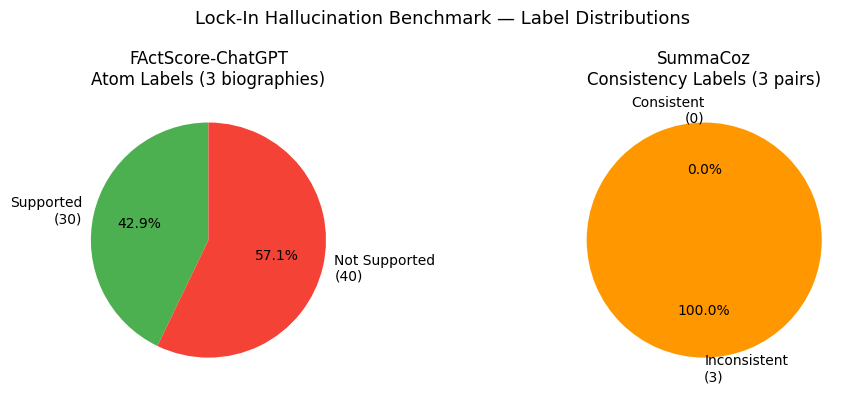

Plot saved to benchmark_summary.png


In [9]:
print("=" * 60)
print("BENCHMARK SUMMARY")
print("=" * 60)

# FActScore stats
total_atoms = sum(ex["metadata_n_atoms"] for ex in factscore)
total_supported = sum(ex["metadata_n_supported"] for ex in factscore)
total_not_supported = sum(ex["metadata_n_not_supported"] for ex in factscore)
halluc_rate = total_not_supported / total_atoms if total_atoms > 0 else 0

print(f"\nFActScore-ChatGPT ({len(factscore)} biographies)")
print(f"  Total atoms:       {total_atoms}")
print(f"  Supported (S=1):   {total_supported} ({100*total_supported/total_atoms:.1f}%)")
print(f"  Not Supported:     {total_not_supported} ({100*halluc_rate:.1f}%)")
print(f"  Avg atoms/bio:     {total_atoms/len(factscore):.1f}")

# SummaCoz stats
n_inconsistent = sum(1 for ex in summacoz if ex["output"] == "0")
n_consistent = sum(1 for ex in summacoz if ex["output"] == "1")

print(f"\nSummaCoz ({len(summacoz)} article/summary pairs)")
print(f"  Inconsistent (0):  {n_inconsistent} ({100*n_inconsistent/len(summacoz):.1f}%)")
print(f"  Consistent (1):    {n_consistent} ({100*n_consistent/len(summacoz):.1f}%)")

print(f"\nTotal examples:      {total}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Lock-In Hallucination Benchmark — Label Distributions", fontsize=13)

# FActScore: atom-level support breakdown
ax1 = axes[0]
counts_fs = [total_supported, total_not_supported]
labels_fs = [f"Supported\n({total_supported})", f"Not Supported\n({total_not_supported})"]
colors_fs = ["#4caf50", "#f44336"]
wedges, texts, autotexts = ax1.pie(counts_fs, labels=labels_fs, colors=colors_fs, autopct="%1.1f%%", startangle=90)
ax1.set_title(f"FActScore-ChatGPT\nAtom Labels ({len(factscore)} biographies)")

# SummaCoz: consistency labels
ax2 = axes[1]
counts_sc = [n_inconsistent, n_consistent]
labels_sc = [f"Inconsistent\n({n_inconsistent})", f"Consistent\n({n_consistent})"]
colors_sc = ["#ff9800", "#2196f3"]
wedges2, texts2, autotexts2 = ax2.pie(counts_sc, labels=labels_sc, colors=colors_sc, autopct="%1.1f%%", startangle=90)
ax2.set_title(f"SummaCoz\nConsistency Labels ({len(summacoz)} pairs)")

plt.tight_layout()
plt.savefig("benchmark_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Plot saved to benchmark_summary.png")